## Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


## Load dataset

In [2]:
data=pd.read_csv("/content/Housing.csv")

data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Information

In [ ]:
data.info()

counting only real value not NAN values

In [39]:
data.count()

,0
price,545
area,545
bedrooms,545
bathrooms,545
stories,545
mainroad,545
guestroom,545
basement,545
hotwaterheating,545
airconditioning,545


Statistics

In [ ]:
data.describe()

## Check missing values

In [ ]:
data.isnull().sum()

## check duplicate rows

In [6]:
data.duplicated().sum()

np.int64(0)

## If duplicate exist

In [7]:
data.drop_duplicates(inplace=True)

## Exporatory data analysis
Target Distribution


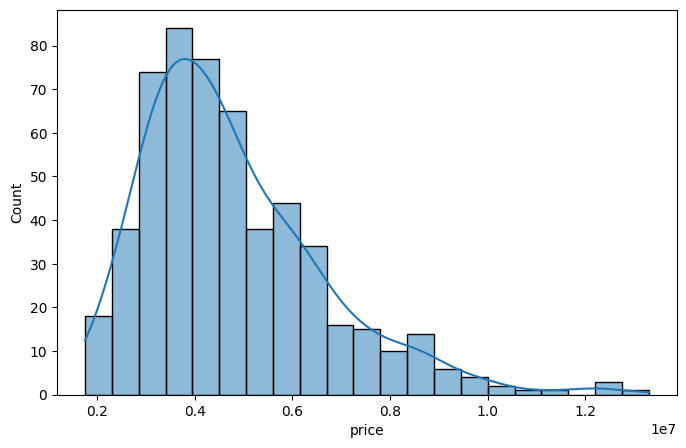

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data["price"],kde=True)
plt.show()

## correlation
first convert Yes/No columns.

In [11]:
binary_columns=[
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"

]
for col in binary_columns:
  data[col]=data[col].map({'yes':1,'no':0})


## Now correlation

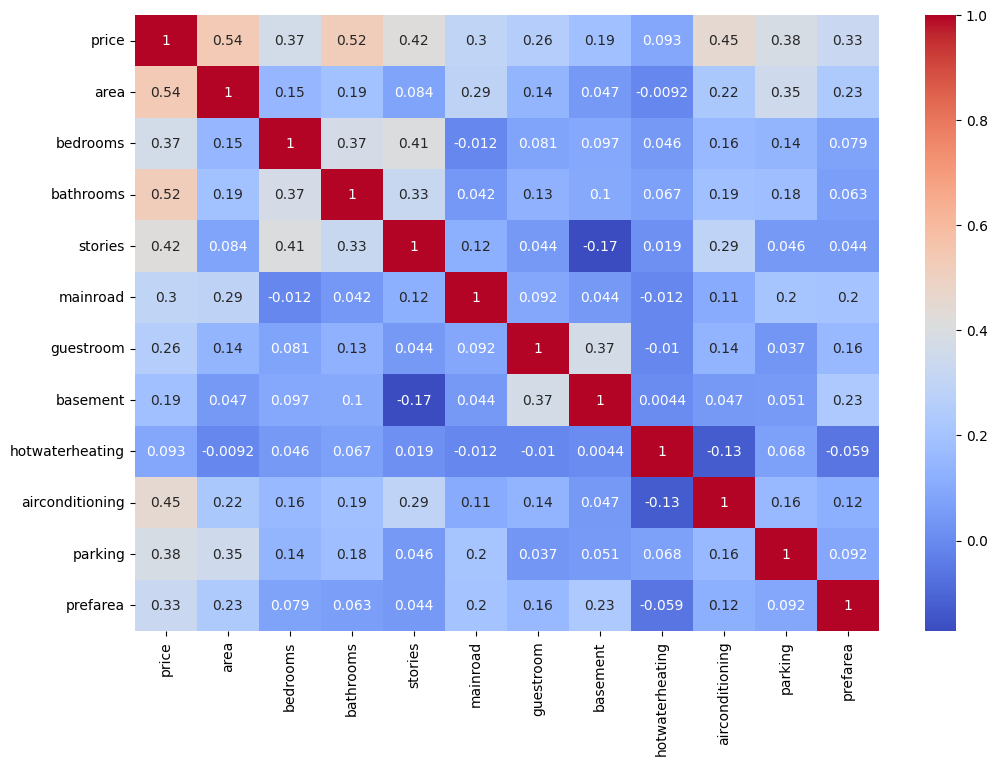

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()


## scatterplot

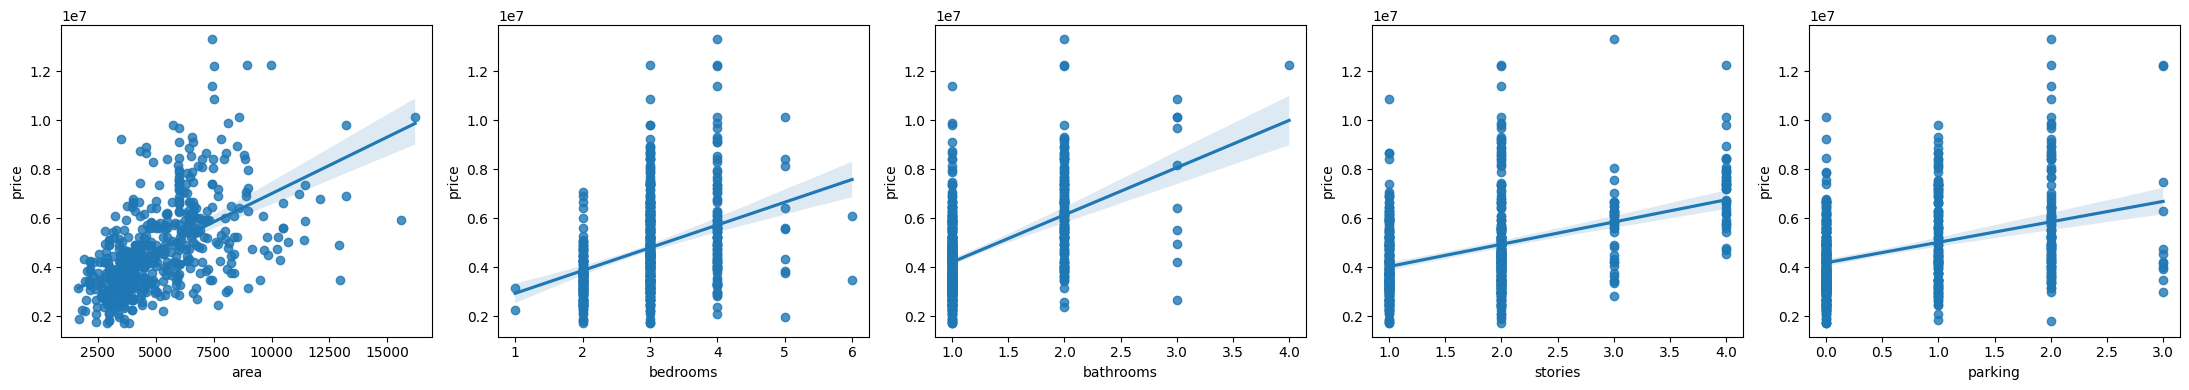

In [13]:
features=['area','bedrooms','bathrooms','stories','parking']

fig,axes=plt.subplots(1,5,figsize=(22,4))

for i,col in enumerate(features):
  sns.regplot(
      x=data[col],
      y=data['price'],
      ax=axes[i]
  )
plt.tight_layout()
plt.show()

## Feaature engineering
Only one categorical column remaining ** furnishingstaatus ** convert that using one hot encoding

In [14]:
data=pd.get_dummies(data,columns=['furnishingstatus'],drop_first=True)

noe check

In [16]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


## Define X and Y

In [19]:
X=data.drop("price",axis=1)
y=data["price"]


## Train Test Split

In [20]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step - 9 Train Then model

In [23]:
model=LinearRegression()
model.fit(X_train,y_train)



LinearRegression()

## Step 10 Prediction

In [24]:
y_pred=model.predict(X_test)

## Step 11 - Evaluation

 - MAE- Mean Absolute Error

In [26]:
mae=mean_absolute_error(y_test,y_pred)
print(mae)

970043.4039201637


## MSE

In [27]:
mse=mean_squared_error(y_test,y_pred)
print(mse)

1754318687330.6633


## RMSE

In [29]:
rmse=np.sqrt(mse)
print(rmse)

1324506.9600914384


## R square Score

In [30]:
r_square=r2_score(y_test,y_pred)
print(r_square)

0.6529242642153185


## Coefficients :- How much each feature influencing house price

In [32]:
coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

coef.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


## Actual Vs predicted Price

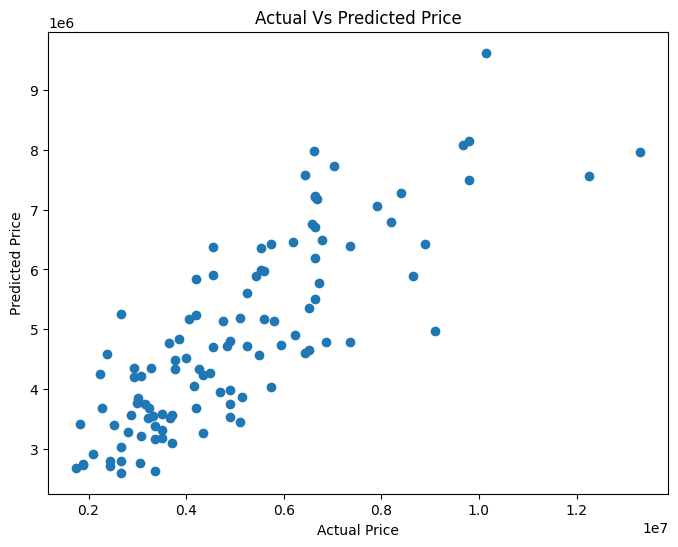

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual Vs Predicted Price")

plt.show()


## Residual Plot

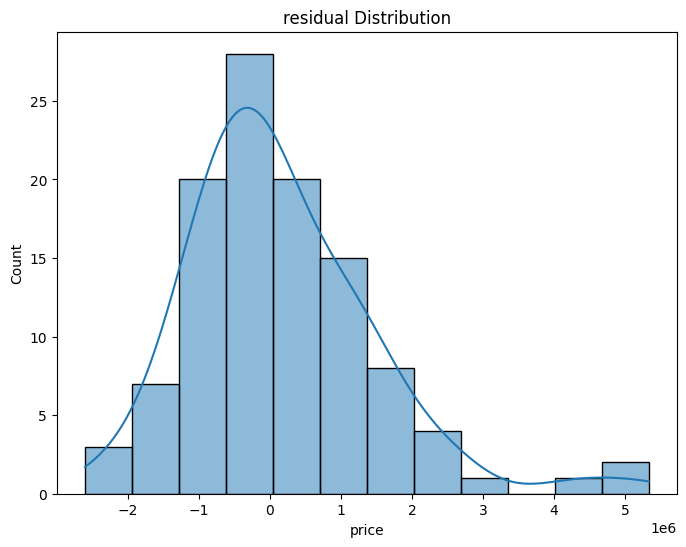

In [34]:
residual=y_test-y_pred

plt.figure(figsize=(8,6))
sns.histplot(residual,kde=True)
plt.title("residual Distribution")
plt.show()

## Step 15 - Predicting new House


In [35]:
new_house = pd.DataFrame({

'area':[6500],
'bedrooms':[3],
'bathrooms':[2],
'stories':[2],
'mainroad':[1],
'guestroom':[0],
'basement':[1],
'hotwaterheating':[0],
'airconditioning':[1],
'parking':[2],
'prefarea':[1],
'furnishingstatus_semi-furnished':[0],
'furnishingstatus_unfurnished':[0]

})

prediction = model.predict(new_house)

print(prediction)

[7657180.7057711]
